<a href="https://colab.research.google.com/github/marianaolmedo/Investigacion-de-Operaciones/blob/main/Inventario_de_varios_art%C3%ADculos_con_limitaci%C3%B3n_de_almac%C3%A9n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inventario de varios artículos con limitación de almacén

Este modelo se aplica al caso en que se manejan $n (>1)$ artículos de inventario, cada uno con demanda conocida y constante, sin permitir faltantes. El nivel de inventario de cada artículo sigue el patrón clásico del modelo EOQ; sin embargo, a diferencia del caso independiente, los artículos compiten por un espacio limitado de almacenamiento, lo que introduce una restricción adicional al problema.

Para cada artículo $i=1,2,…,n$ se definen los siguientes parámetros:


*   $D_i:$ tasa de demanda del artículo $i$
*   $K_i:$ costo de preparación o pedido
*   $h_i:$ costo unitario de almacenamiento por unidad de tiempo
*   $y_i:$ cantidad de pedido del artículo $i$
*   $a_i:$ área de almacenamiento requerida por unidad del artículo $i$
*   $A:$ área total disponible para almacenamiento


Bajo estas condiciones, el costo total promedio por unidad de tiempo del sistema está dado por:

$$TCU(y_1, y_2,...,y_n) = \sum_{i=1}^n \left( \frac{K_i D_i}{y_i} + \frac{h_iy_i}{2}\right) $$
sujeto a la restricción de espacio:
$$ \sum _{i=1}^n a_iy_i \leq A, \hspace{0.7cm} y_i>0 $$

# **Método de solución**

El procedimiento para resolver el siguiente problema consta de tres pasos:

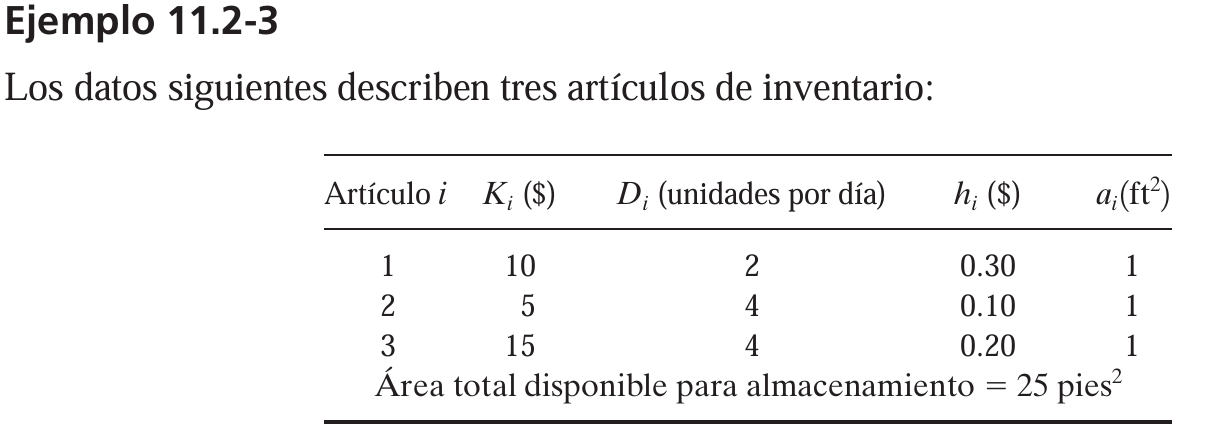

**Poner las librerias necesarias para hacer funcionar el código:**

In [11]:
import sympy as sp
import numpy as np
from scipy.optimize import root_scalar


**Definición de datos del problema**

In [12]:
# Datos del problema
K = np.array([10, 5, 15])      # Costos de preparación Ki
D = np.array([2, 4, 4])        # Demandas Di
h = np.array([0.30, 0.10, 0.20])  # Costos de almacenamiento hi
a = np.array([1, 1, 1])        # Área por unidad ai
A = 25                         # Área total disponible
n = len(K)


**Paso 1. Solución no restringida**

Se calculan las cantidades óptimas de pedido ignorando la restricción de almacenamiento, resolviendo cada artículo como un EOQ independiente:
$$ y^*_i = \sqrt{\frac{2K_iD_i}{h_i}}, \hspace{0.5cm} i = 1,2,...,n$$

In [16]:
y_nr = np.sqrt((2 * K * D )/ h)
y_nr


array([11.54700538, 20.        , 24.49489743])

**Paso 2. Verificar restricción de almacenamiento**

Se verifica si las cantidades obtenidas en el Paso 1 satisfacen la restricción de almacenamiento:

$$\sum_{i=1}^n a_i y^*_i \leq A $$
Si la desigualdad se cumple, la solución no restringida es óptima y el procedimiento termina.

Si no se cumple, se procede al Paso 3.

In [19]:
area= np.sum(a * y_nr)
print(area)
if area <= A:
    print("La solución NO restringida es factible.")
else:
    print("La solución NO restringida NO es factible. Pasar al Paso 3.")


56.0419028116243
La solución NO restringida NO es factible. Pasar al Paso 3.


**Paso 3: Formulación con multiplicadores de Lagrange**

Cuando la restricción de almacenamiento es activa, el problema se resuelve utilizando el método de los multiplicadores de Lagrange, formulando la función:

$$ L(y_1, ..., y_n, λ) = \sum_{i_1}^n \left( \frac{K_i D_i}{y_i} + \frac{h_iy_i}{2}\right) - λ \left(\sum_{i=1}^n a_iy_i -A\right)$$

De las condiciones de primer orden se obtiene que las cantidades óptimas tienen la forma:

$$ y_i (λ) \sqrt{\frac{2K_iD_i}{h_i - 2 λ a_i}} , \hspace{0.6cm} λ <0 $$



In [20]:
def y_lambda(lmbda):
    return np.sqrt((2 * K * D) / (h - 2 * lmbda * a))

def c(lmbda):
    return np.sum(a * y_lambda(lmbda)) - A


El valor óptimo $λ^*$ se determina de manera numérica, de forma que las cantidades $y_i(λ^*)$ satisfagan la restricción de almacenamiento como igualdad:
$$ \sum_{i=1}^n a_iy_i(λ^*) = A $$


In [21]:
sol = root_scalar(
    c,
    bracket=[-10, -1e-6],  # λ < 0
    method='bisect'
)

lambda_ast = sol.root
lambda_ast


-0.34795763196792623

Cantidades óptimas restringidas:

In [22]:
y_opt = y_lambda(lambda_ast)
y_opt


array([ 6.3375121 ,  7.08918939, 11.57329851])

**Verificación final del área:**

Una vez obtenido $λ^*$ , las cantidades correspondiente $y_i^*$ constituyen la solución óptima restringida del problema.

In [9]:
np.sum(a * y_opt)


np.float64(24.999999999969116)

Para finalizar agregamos el Costo total mínimo

In [23]:
TCU = np.sum(K * D / y_opt + h * y_opt / 2)
TCU


np.float64(13.623773069851985)